<a href="https://colab.research.google.com/github/Arjun-08/Image-Denoising-Using-Gaussian-Low-Pass-Filter/blob/main/image_denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Image Denoising Using Gaussian Low-Pass Filter**

Noise in images is often introduced due to sensor limitations, transmission errors, or environmental conditions. One common approach to denoising is applying a Gaussian low-pass filter, which smooths the image by reducing high-frequency noise while preserving important structures.

The noisy image y(m,n) is denoised using a convolution with a Gaussian-weighted window:

   𝑥^(𝑚,𝑛) = Σ Σ 𝑤(𝑘,𝑙) 𝑦(𝑚+𝑘,𝑛+𝑙)

where the Gaussian filter weights are given by:

    𝑤(𝑘,𝑙) = C exp(- (𝑘^2 + 𝑙^2) / 2𝜎^2)

 with normalization:

    Σ Σ 𝑤(𝑘,𝑙) = 1
 P represents the filter window size (set to 11 × 11), and σ is the standard  deviation, controlling the degree of smoothing. The larger the σ, the stronger the smoothing effect.

,Image,Best Sigma,Best MSE,Best SSIM
0,/content/img108.bmp,1.0,159.816910,0.652035
1,/content/img125.bmp,0.1,15.624776,0.900412
2,/content/img137.bmp,4.0,1600.062134,0.171411
3,/content/img6.bmp,0.1,49.935772,0.765028
4,/content/img32.bmp,1.0,204.307480,0.563777


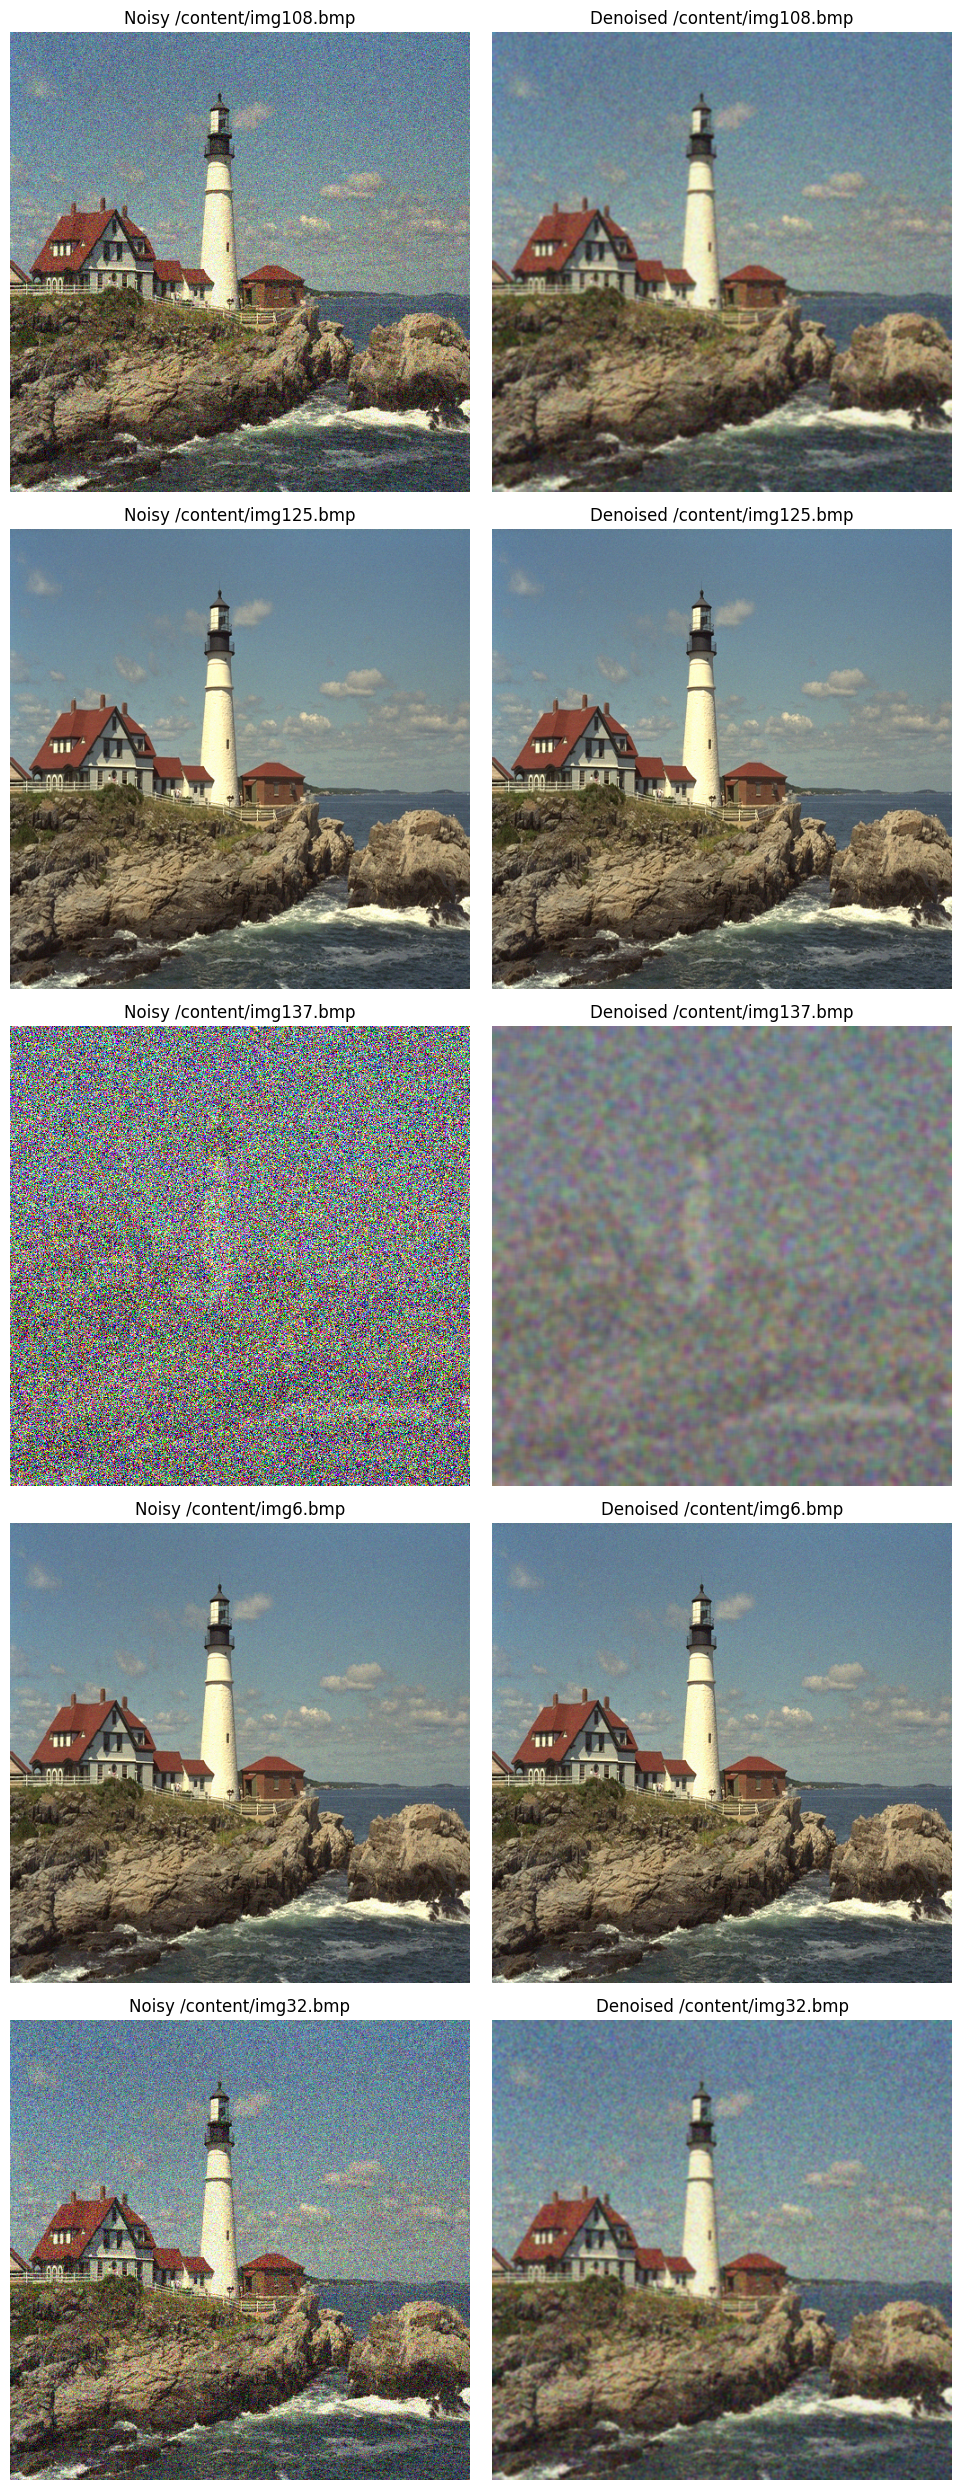

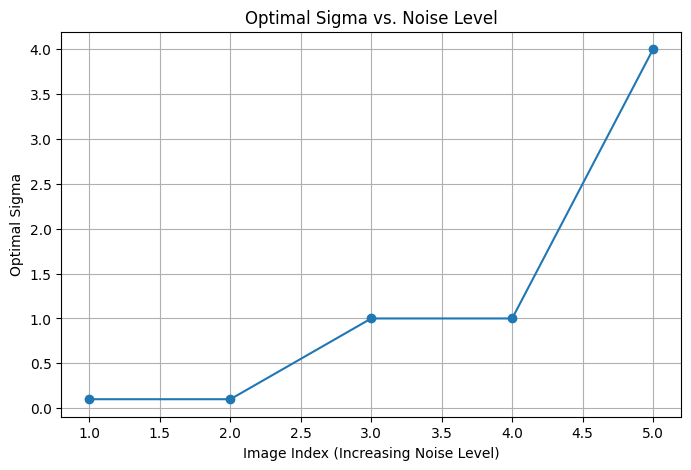

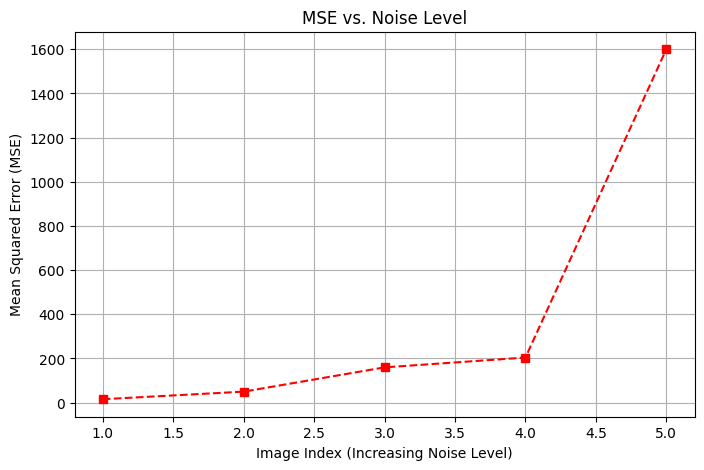

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import pandas as pd
from IPython.display import display

# Function to apply Gaussian filter to an image

def apply_gaussian_filter(image, sigma):
    """
    Applies a Gaussian blur filter to the image with a given standard deviation (sigma).
    The filter is applied using an 11x11 kernel.
    """
    return cv2.GaussianBlur(image, (11, 11), sigma)

# Function to apply Gaussian filter to each channel (R, G, B) separately

def apply_gaussian_filter_rgb(image, sigma):
    """
    Applies a Gaussian filter to each RGB channel separately and merges them back.
    This ensures noise reduction while preserving color structure.
    """
    b, g, r = cv2.split(image)
    b_filtered = apply_gaussian_filter(b, sigma)
    g_filtered = apply_gaussian_filter(g, sigma)
    r_filtered = apply_gaussian_filter(r, sigma)
    return cv2.merge([b_filtered, g_filtered, r_filtered])


# Function to compute Mean Squared Error (MSE) between two images
def compute_mse(image1, image2):
    """
    Computes the Mean Squared Error (MSE) between two images.
    MSE formula:
        MSE = (1/N) * Σ (I1 - I2)^2
    where N is the total number of pixels.
    """
    return np.mean((image1.astype(np.float32) - image2.astype(np.float32)) ** 2)

# Load the reference image (ground truth)
reference_image = cv2.imread('/content/img167.bmp')  # Reference image
reference_image = cv2.resize(reference_image, (512, 512))
ref_height, ref_width, _ = reference_image.shape  # Get dimensions


# Define the set of standard deviations (σ) for the Gaussian filter
sigmas = [0.1, 1, 2, 4, 8]


# List of noisy images to be denoised
image_filenames = [
    '/content/img108.bmp',
    '/content/img125.bmp',
    '/content/img137.bmp',
    '/content/img6.bmp',
    '/content/img32.bmp',
]


# 1. Each noisy image is denoised using a Gaussian filter with different standard deviations (σ).
# 2. Compute MSE and SSIM between each denoised image and the reference image.
# 3. Choose the best σ based on lowest MSE and highest SSIM.

results = []
best_images = []

for img_filename in image_filenames:
    noisy_image = cv2.imread(img_filename)  # Read noisy image
    noisy_image = cv2.resize(noisy_image, (ref_width, ref_height))

    best_mse, best_ssim, best_sigma = float('inf'), -1, None
    best_filtered_rgb = None

    # Iterate over different σ values
    for sigma in sigmas:
        filtered_rgb = apply_gaussian_filter_rgb(noisy_image, sigma)  # Apply Gaussian filter
        mse = compute_mse(filtered_rgb, reference_image)  # Compute MSE
        ssim_value = ssim(filtered_rgb, reference_image, channel_axis=2,
                          data_range=filtered_rgb.max() - filtered_rgb.min())  # Compute SSIM

        # Store best filter settings based on MSE
        if mse < best_mse:
            best_mse, best_ssim, best_sigma = mse, ssim_value, sigma
            best_filtered_rgb = filtered_rgb

    # Append results
    results.append((img_filename, best_sigma, best_mse, best_ssim))
    best_images.append((noisy_image, best_filtered_rgb))

results_df = pd.DataFrame(results, columns=['Image', 'Best Sigma', 'Best MSE', 'Best SSIM'])
display(results_df)


fig, axes = plt.subplots(len(image_filenames), 2, figsize=(10, len(image_filenames) * 5))
for i, (noisy, denoised) in enumerate(best_images):
    axes[i, 0].imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f'Noisy {image_filenames[i]}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title(f'Denoised {image_filenames[i]}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


# Plot optimal sigma vs. increasing noise level
sorted_indices = [i[0] for i in sorted(enumerate(best_images), key=lambda x: compute_mse(x[1][0], reference_image))]
best_sigmas_sorted = [results[i][1] for i in sorted_indices]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(best_sigmas_sorted) + 1), best_sigmas_sorted, marker='o', linestyle='-')
plt.xlabel('Image Index (Increasing Noise Level)')
plt.ylabel('Optimal Sigma')
plt.title('Optimal Sigma vs. Noise Level')
plt.grid()
plt.show()


# Plot MSE for each image
mse_values = [results[i][2] for i in sorted_indices]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mse_values) + 1), mse_values, marker='s', linestyle='--', color='r')
plt.xlabel('Image Index (Increasing Noise Level)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs. Noise Level')
plt.grid()
plt.show()
